# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import shap
import joblib

In [2]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Exploratory Data Analysis(EDA)

In [3]:
df.shape

(32581, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
print(f"Unique values: {df['loan_status'].unique()}")

Unique values: [1 0]


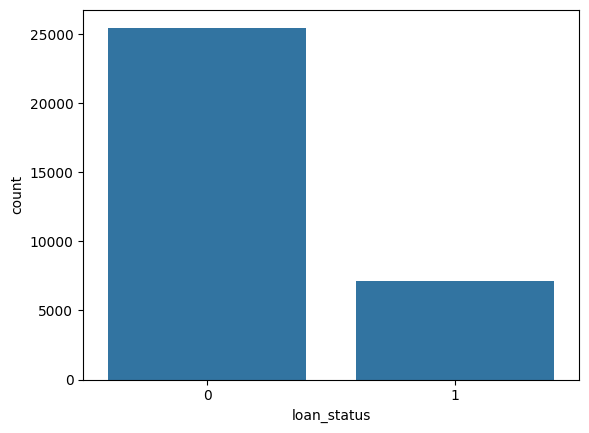

In [7]:
sns.countplot(x='loan_status', data=df)
plt.show()

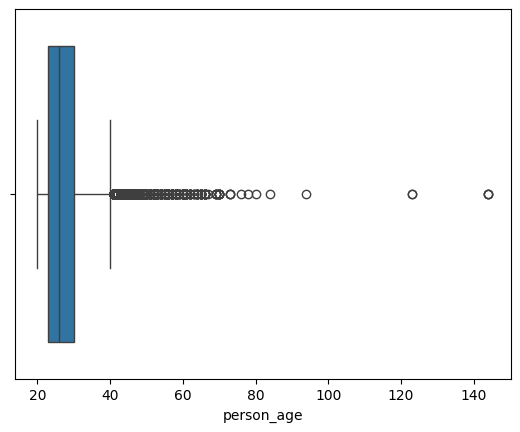

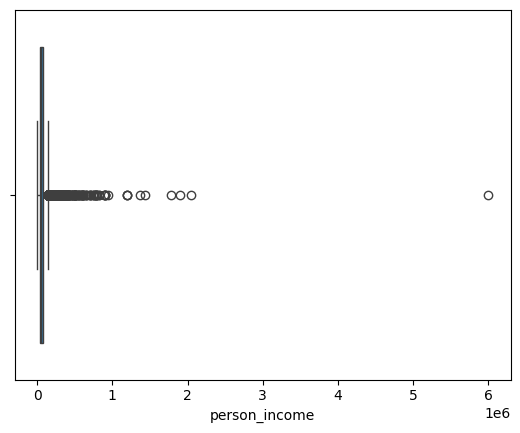

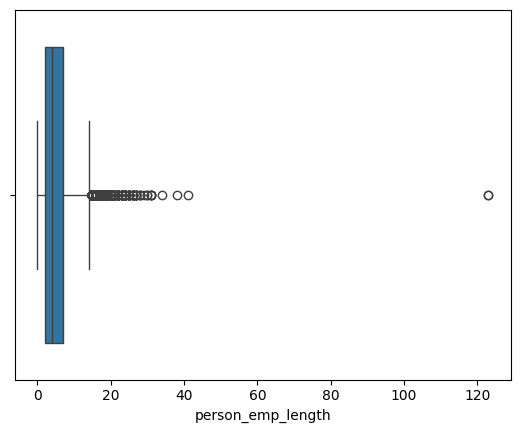

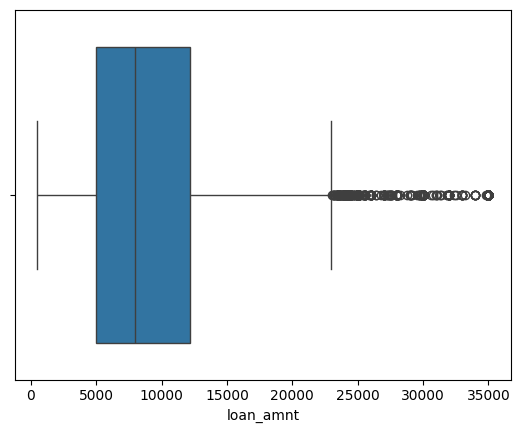

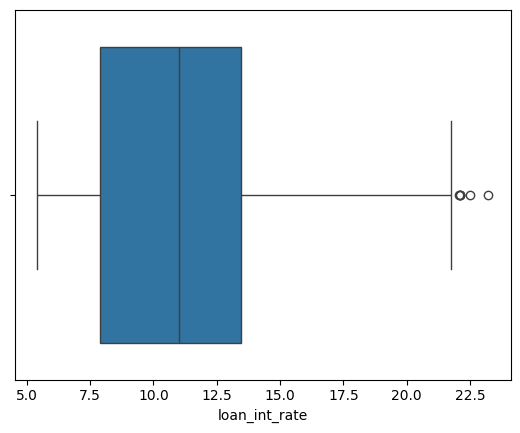

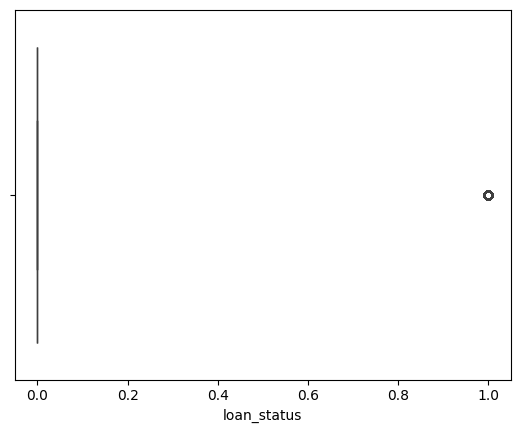

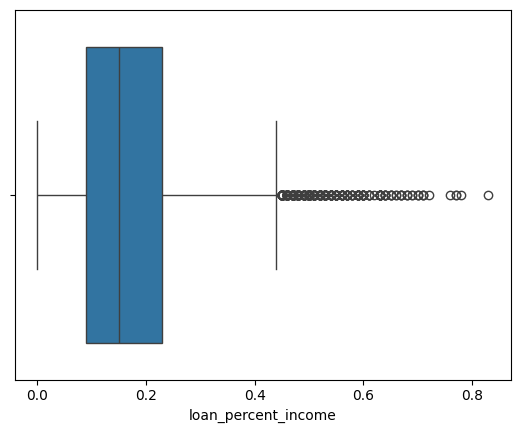

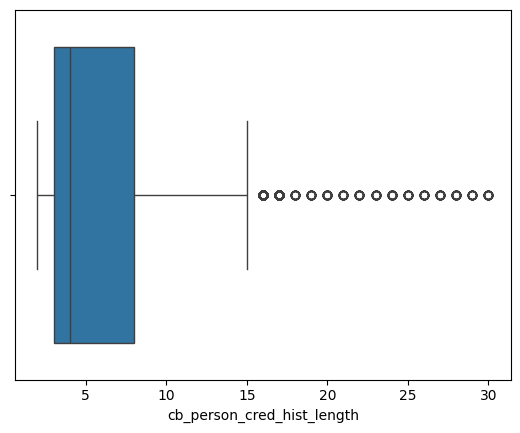

In [8]:
num_cols = df.select_dtypes(include=np.number).columns

for i in num_cols:
  sns.boxplot(x=df[i])
  plt.show()

In [9]:
(df['person_age'] > 100).sum()

np.int64(5)

In [10]:
(df['person_emp_length'] > 60).sum()

np.int64(2)

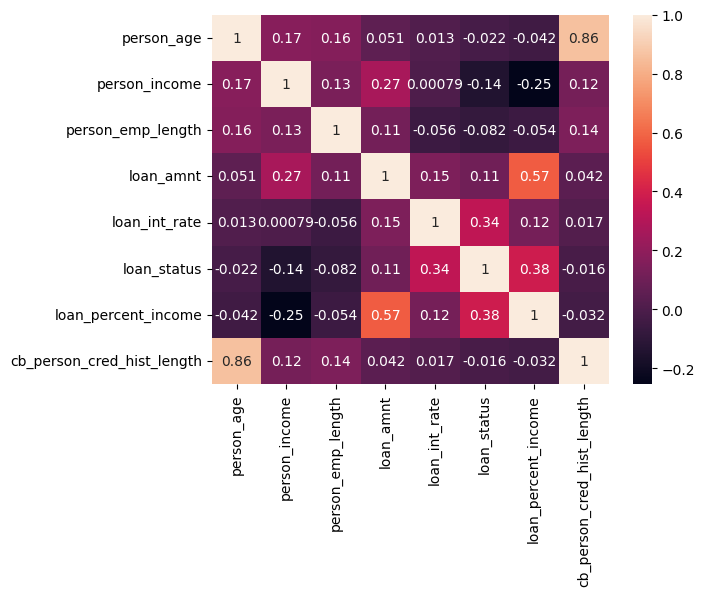

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Validation and Outlier Handling

In [12]:
df_copy = df.copy()

print(f"Original Rows: {df_copy.shape[0]}")

# Remove dupliicate rows
df_copy.drop_duplicates(inplace=True)
print(f"After removing duplicate rows: {df_copy.shape[0]}")

# Remove ages below 18 or above 100
df_copy = df_copy[(df_copy['person_age'] >= 18) & (df_copy['person_age'] <= 100)]

# Remove employement length greater than age or extreme  outliers (>60)
df_copy = df_copy[(df_copy['person_emp_length'] <= df_copy['person_age'])]
df_copy = df_copy[df_copy['person_emp_length'] <= 60]

# Remove the rows with zero or negative income and loan amount
df_copy = df_copy[df_copy['loan_amnt'] > 0]

print("Loan interest rate range from (min: 5.42) and (max: 23.22)")

Original Rows: 32581
After removing duplicate rows: 32416
Loan interest rate range from (min: 5.42) and (max: 23.22)


# Feature, Target & Train-Test Split

In [13]:
X = df_copy.drop('loan_status', axis=1)
y = df_copy['loan_status']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# Handle Class Imbalance

In [16]:
# Class Weights
neg, pos = np.bincount(y_train)
scale_weights = neg / pos
print(scale_weights)

3.6312213039485766


# Data Preprocessing - Pipelines & Column Transformer

In [17]:
# Logistic Regression : Impute + SCALE numeric, impute + OHE
preprocessor_lr = ColumnTransformer(
    transformers=[
        # Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_cols),

        # Pipeline for categorical columns
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

# Preprocessing For XGBoost

In [18]:
# XGBoost: Impute numeric only

preprocessor_xg = ColumnTransformer(
    transformers=[
        # Pipeline for numerical columns
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), numeric_cols),

        # Pipeline for categorical columns
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ]
)

# Evaluation Helper Function

In [26]:
def evaluate_model(model_name, model, X_test, y_test, threshold=None):
  y_pred_proba = model.predict_proba(X_test)[:,1]

  if threshold is not None:
    y_pred = (y_pred_proba >= threshold).astype(int)
  else:
    y_pred = model.predict(X_test)
    threshold = 0.5
  # Metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  print(f"Model: {model_name}")
  print(f"Best Threshold: {threshold:.2f}")
  print(f"Accuracy: {accuracy:.2f}")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1 Score: {f1:.2f}")

  # Confusion Matrix
  cm = confusion_matrix(y_test, y_pred)
  class_report = classification_report(y_test, y_pred)

  print(f"Classification Report:\n{class_report}")
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  # Plotting ROC-AUC Curve
  precisions, recalls, threshold = precision_recall_curve(y_test, y_pred_proba)
  plt.plot(precisions, recalls, label='Precision-Recall Curve')
  plt.xlabel('Precision')
  plt.ylabel('Recall')
  plt.title('Precision-Recall Curve')
  plt.show()

# Stratified Cross Validation

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {'roc_auc': 'roc_auc', 'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

In [28]:
# Logistic Regression
lr_cv_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]
)

lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [29]:
# XGBoost Model
xgb_cv_pipeline = Pipeline([
    ('preprocessor', preprocessor_xg),
    ('classifier', XGBClassifier(
        n_estimators = 300,
        max_depth = 5,
        learning_rate = 0.1,
        scale_pos_weight = scale_weights,
        random_state = 42,
        n_jobs = -1
    ))
])
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oneh...
                               gamma=None, gpu_id=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=5,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, predictor=None,
                               random_state=42, reg_alpha=None, reg_lambda=None, ...))])

In [30]:
for cv_name, pipe in [('Logistic Regression', lr_cv_pipeline), ('XGBoost', xgb_cv_pipeline)]:
  cv_results = cross_validate(
      estimator = pipe,
      X = X_train,
      y = y_train,
      cv = cv,
      scoring = scoring,
      n_jobs = -1
  )

  print(f"CV Results for {cv_name}:")
  print(f"ROC AUC: {cv_results['test_roc_auc'].mean()}")
  print(f"Accuracy: {cv_results['test_accuracy'].mean()}")
  print(f"Precision: {cv_results['test_precision'].mean()}")
  print(f"Recall: {cv_results['test_recall'].mean()}")
  print(f"F1 Score: {cv_results['test_f1'].mean()}")
  print("-"*40)

CV Results for Logistic Regression:
ROC AUC: 0.8664048625259755
Accuracy: 0.8057656493568475
Precision: 0.5345772683788906
Recall: 0.7794306703397613
F1 Score: 0.6341015225098443
----------------------------------------
CV Results for XGBoost:
ROC AUC: 0.9497760882769251
Accuracy: 0.9202124457657799
Precision: 0.8244770702931291
Recall: 0.8018365472910928
F1 Score: 0.812724333804533
----------------------------------------


# Baseline Model Logistic Regression

In [31]:
baseline_model = Pipeline(
    steps = [
        ('preprocessor', preprocessor_lr),
        ('classifier', LogisticRegression(class_weight='balanced'))
    ]
)
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

Model: Baseline Logistic Model
Best Threshold: 0.50
Accuracy: 0.81
Precision: 0.54
Recall: 0.78
F1 Score: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4943
           1       0.54      0.78      0.64      1362

    accuracy                           0.81      6305
   macro avg       0.74      0.80      0.76      6305
weighted avg       0.85      0.81      0.82      6305



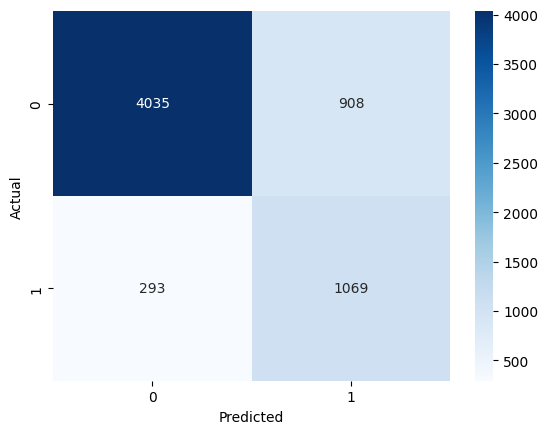

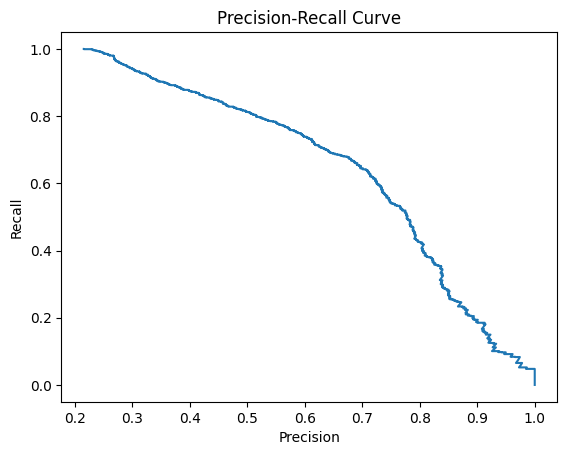

In [32]:
# Evaluate the Logistic Model
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

# XGBoost Hyperparameter Tuning

In [33]:
xg_model= Pipeline(
    steps = [
        ('preprocessor', preprocessor_xg),
        ('classifier', XGBClassifier(learning_rate = 0.1, scale_pos_weight=scale_weights, random_state=42))
    ]
)
xg_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('oneh...
                               gamma=0, gpu_id=-1, grow_policy='depthwise',
                               importance_type=None, interaction_constraints='',
                               learning_rate=0.1, max_bin=256,
                               max_cat_to_onehot=4, max_delta_step=0,
                               max_depth=6, max_leaves=0, min_child_weight=1,
                               missing=nan, monotone_constraints='()',
                               n_estimators=100, n_jobs=0, num_parallel_tree=1,
                               predictor='auto', random_state=42, reg_alpha=0,
                               reg_lambda=1, ...))])

Model: XGBoost Model
Best Threshold: 0.50
Accuracy: 0.92
Precision: 0.82
Recall: 0.79
F1 Score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.81      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



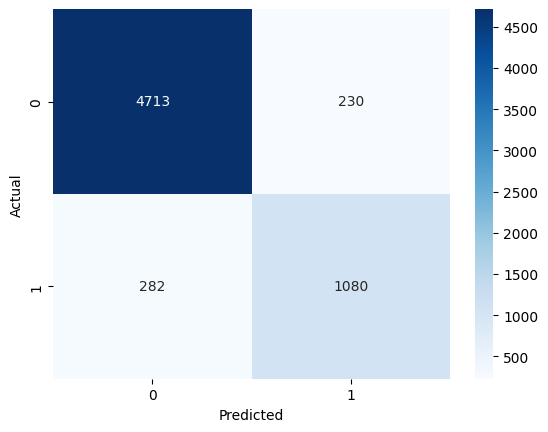

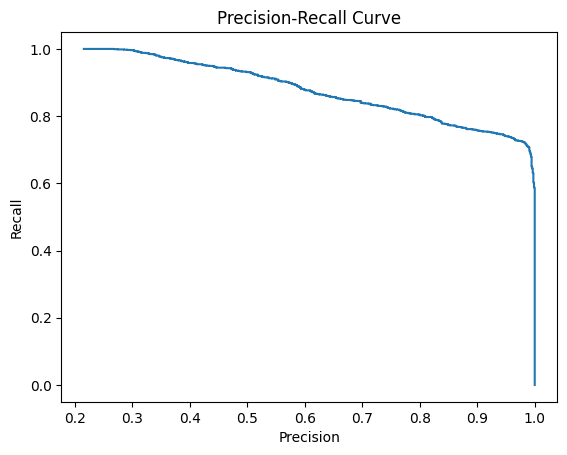

In [34]:
# Evaluate Base XGBoost
evaluate_model("XGBoost Model", xg_model, X_test, y_test)

In [35]:
param_grid = {
    "classifier__n_estimators": randint(150,600),
    "classifier__max_depth": randint(3,9),
    "classifier__learning_rate": uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6, 0.4),  # Row Sampling
    "classifier__colsample_bytree": uniform(0.6, 0.4), # Column Sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0, 5)
}

In [36]:
random_search_cv = RandomizedSearchCV(
    xg_model,
    param_grid,
    n_iter = 150,
    cv = cv,
    scoring = 'average_precision',
    n_jobs = -1,
    verbose = 1
)

In [37]:
random_search_cv.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_length']),
                                                                              ('cat',
                                                                               P...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000016230CF82D0>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001622D3A3CB0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000016230D1BED0>},
                   scoring='average_precision', verbose=1)

In [38]:
random_search_cv.best_params_

{'classifier__colsample_bytree': np.float64(0.670155623152581),
 'classifier__gamma': np.float64(2.224626402050132),
 'classifier__learning_rate': np.float64(0.10722815695318587),
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 5,
 'classifier__n_estimators': 599,
 'classifier__subsample': np.float64(0.9466016162002966)}

In [39]:
print(f"Score after performing Tunning: {random_search_cv.best_score_ * 100:.2f}")

Score after performing Tunning: 90.69


# Compare Both Models Side by Side

Model: Baseline Logistic Model
Best Threshold: 0.50
Accuracy: 0.81
Precision: 0.54
Recall: 0.78
F1 Score: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4943
           1       0.54      0.78      0.64      1362

    accuracy                           0.81      6305
   macro avg       0.74      0.80      0.76      6305
weighted avg       0.85      0.81      0.82      6305



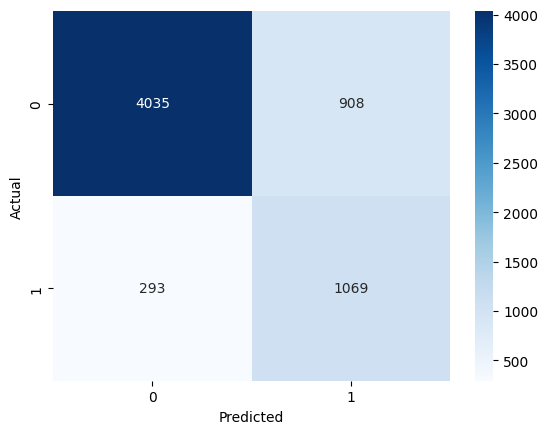

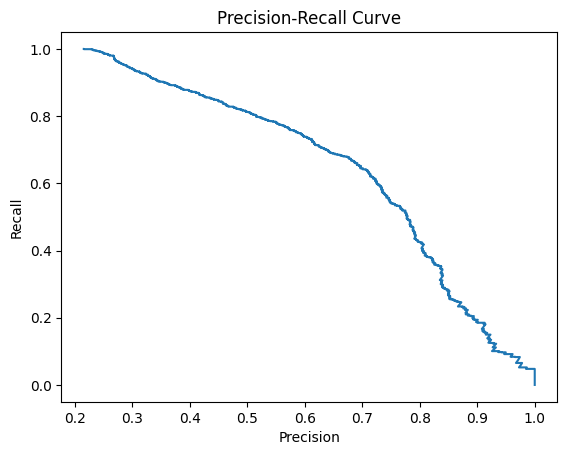

In [40]:
evaluate_model("Baseline Logistic Model", baseline_model, X_test, y_test)

Model: XGBoost Model
Best Threshold: 0.50
Accuracy: 0.92
Precision: 0.82
Recall: 0.82
F1 Score: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4943
           1       0.82      0.82      0.82      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.88      0.88      6305
weighted avg       0.92      0.92      0.92      6305



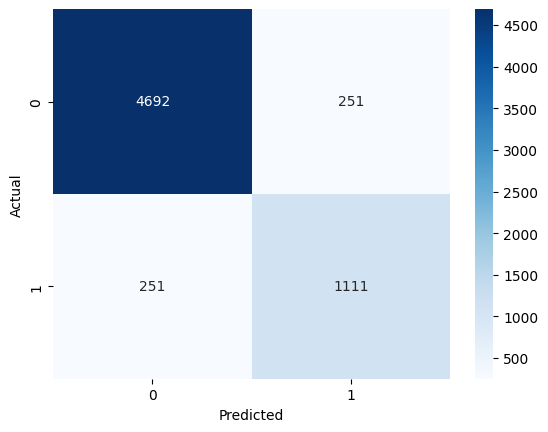

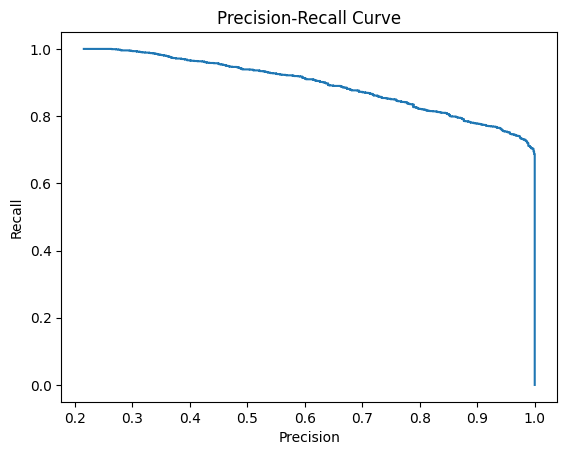

In [41]:
evaluate_model("XGBoost Model", random_search_cv, X_test, y_test)

# Optimising the classification Threshold

In [42]:
# Get the probabilty if class 1 from XGBoost
prob = xg_model.predict_proba(X_test)[:, 1]

# For each threshold calculate Precision and Recall
precissions, recalls, threshold = precision_recall_curve(y_test, prob)

# Calculate F1 score for each threshold
f1 = 2*(precissions * recalls) / (precissions + recalls + 1e-9)

# Get the threshold that produces the highest f1-score
best = np.argmax(f1[:-1])
best_threshold = threshold[best]

print(f"Best Threshold: {best_threshold:.4f}")

Best Threshold: 0.6643


Model: XGBoost
Best Threshold: 0.66
Accuracy: 0.94
Precision: 0.95
Recall: 0.75
F1 Score: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.95      0.75      0.83      1362

    accuracy                           0.94      6305
   macro avg       0.94      0.87      0.90      6305
weighted avg       0.94      0.94      0.93      6305



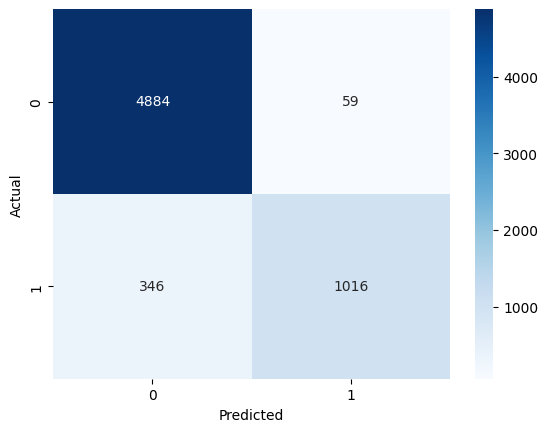

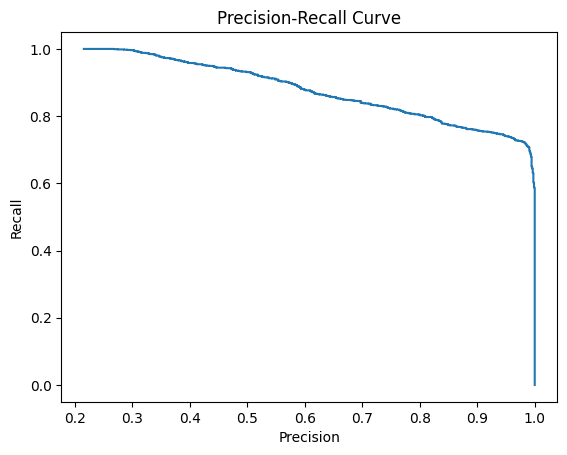

In [43]:
evaluate_model("XGBoost", xg_model, X_test,y_test, best_threshold)

# Probability Calibration

In [44]:
best_model = random_search_cv.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_hist_length']),
                                                                                  ('cat',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(fill_value=...
                                                                grow_policy='depthwise',
                                                                importance_type=None,
                                                                interaction_constraints='',
                                                                learning_rate=np.float64(0.10722815695318587),
                                                                max_bin=256,
                                                                max_cat_to_onehot=4,
                                                                max_delta_step=0,
                                                                max_depth=5,
                                                                max_leaves=0,
                                                                min_child_weight=5,
                                                                missing=nan,
                                                                monotone_constraints='()',
                                                                n_estimators=599,
                                                                n_jobs=0,
                                                                num_parallel_tree=1,
                                                                predictor='auto',
                                                                random_state=42,
                                                                reg_alpha=0,
                                                                reg_lambda=1, ...))]))

In [45]:
# Get probabilities
uncalibrated = xg_model.predict_proba(X_test)[:,1]
calibrated = calibrated_model.predict_proba(X_test)[:,1]

In [46]:
# Create calibration curve
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated, n_bins=10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated, n_bins=10)

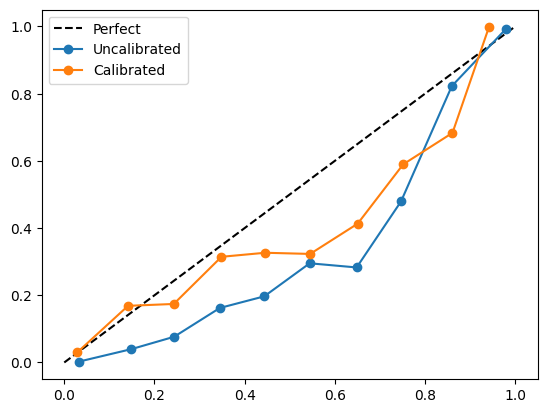

In [47]:
plt.plot([0,1], [0,1], 'k--', label = 'Perfect')
plt.plot(
    predicted_uncal,
    actual_uncal,
    marker='o',
    label = 'Uncalibrated'
)

plt.plot(
    predicted_cal,
    actual_cal,
    marker='o',
    label = 'Calibrated'
)
plt.legend()
plt.show()

# SHAP Interpretation - Global & Local

In [48]:
# Get the trained XGBoost classifier model out of the pipeline
xgb_model = xg_model.named_steps['classifier']
xgb_model

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=42,
              reg_alpha=0, reg_lambda=1, ...)

In [49]:
# Transform X_test using the same preprocessing used for training
X_test_transformed = xg_model.named_steps['preprocessor'].transform(X_test)

In [50]:
# Get feature names after one hot encoding
feature_names = xg_model.named_steps['preprocessor'].get_feature_names_out()

In [51]:
# Convert to a dataframe for cleaner SHAP plots
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_df.head()

,num__person_age,num__person_income,num__person_emp_length,num__loan_int_rate,num__loan_percent_income,num__cb_person_cred_hist_length,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,...,cat__loan_intent_VENTURE,cat__loan_grade_A,cat__loan_grade_B,cat__loan_grade_C,cat__loan_grade_D,cat__loan_grade_E,cat__loan_grade_F,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y
0,24.0,30000.0,1.0,15.68,0.50,3.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,23.0,60000.0,6.0,10.99,0.43,4.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,29.0,18000.0,2.0,15.27,0.20,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,32.0,130000.0,7.0,12.69,0.10,8.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,23.0,45288.0,7.0,9.25,0.45,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [52]:
# Create SHAP explainer built for tree based model
explainer = shap.TreeExplainer(xgb_model)

In [53]:
# Calculate the SHAP values for every row in the test set
shap_values = explainer.shap_values(X_test_df)
shap_values

array([[-7.3881634e-02, -1.4032510e-01,  1.6998859e-01, ...,
        -5.7294238e-03, -2.6956763e-02,  0.0000000e+00],
       [-1.1482277e-02, -8.4947640e-01, -1.0306741e-01, ...,
        -8.6950455e-03, -3.7379193e-03,  0.0000000e+00],
       [ 7.1104124e-02,  3.5103292e+00,  9.3225800e-02, ...,
        -6.0967747e-03, -1.5168138e-03,  0.0000000e+00],
       ...,
       [-2.1776864e-02,  4.4379705e-01,  8.1078738e-02, ...,
        -8.6336629e-03, -1.0884260e-02,  0.0000000e+00],
       [-2.3965368e-02, -9.4884157e-01,  2.5699096e-02, ...,
        -7.4652410e-03, -1.1010252e-02,  0.0000000e+00],
       [-1.3387464e-01, -6.6846776e-01,  7.1207979e-03, ...,
        -9.3692895e-03, -1.0180133e-02,  0.0000000e+00]], dtype=float32)

## GLOBAL explanation

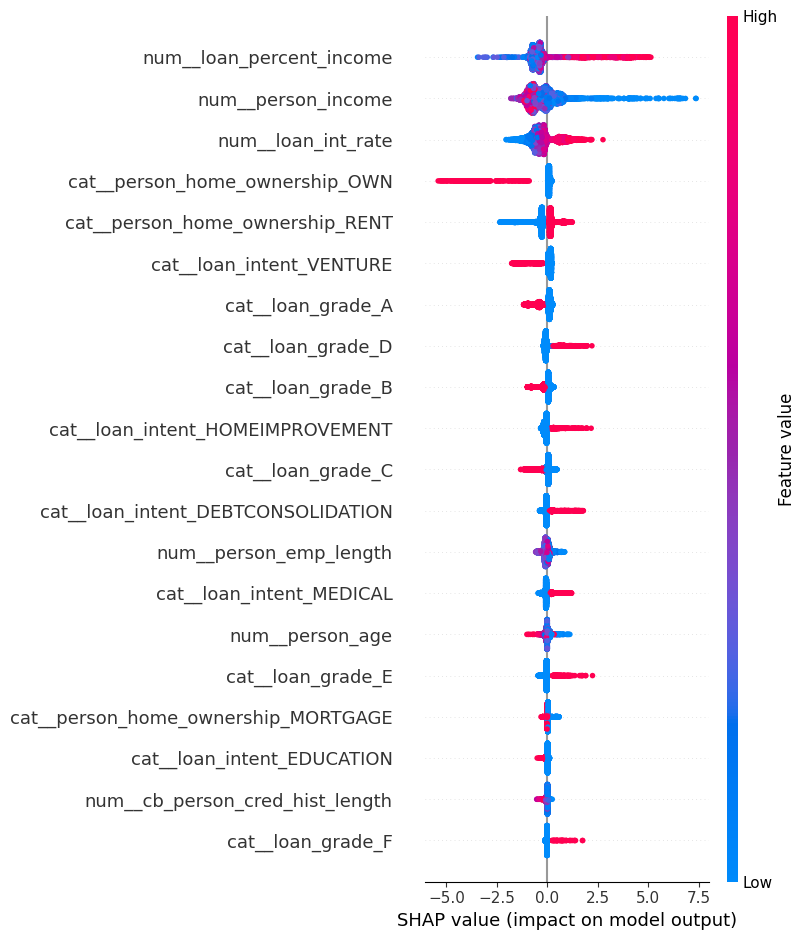

In [54]:
shap.summary_plot(shap_values, X_test_df)

## LOCAL Explaination

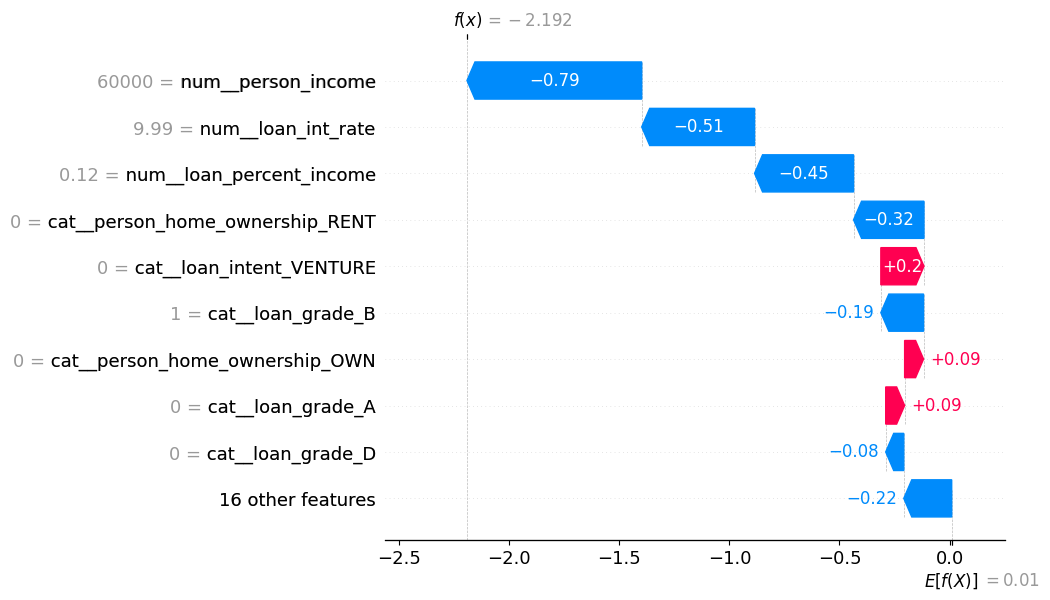

In [55]:
# Pick one row to explain
row_index = 5

# Draw a waterfall plot showing how each feature pushed the prediction up and down
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[row_index],
        base_values = explainer.expected_value,
        data = X_test_df.iloc[row_index],
        feature_names = feature_names
    )
)

# Analyzing False Positive and False Negatives

In [56]:
# Get predictions from the best performing XGBoost model on the test set
y_pred = random_search_cv.predict(X_test)

In [57]:
# Create a dataframe to easily compare the actual and predicted values
result_df = X_test.copy()
result_df['Actual'] = y_test
result_df['Predicted'] = y_pred
result_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual,Predicted
14455,24,30000,OWN,1.0,MEDICAL,E,15000,15.68,0.50,N,3,1,1
8701,23,60000,MORTGAGE,6.0,EDUCATION,C,25600,NaN,0.43,N,4,0,0
19804,29,18000,RENT,2.0,EDUCATION,C,3600,15.27,0.20,N,6,1,1
27252,32,130000,MORTGAGE,7.0,MEDICAL,B,13000,12.69,0.10,N,8,0,0
5610,23,45288,MORTGAGE,7.0,DEBTCONSOLIDATION,B,20500,9.25,0.45,N,2,0,0


In [58]:
# Identify False Positive: Model Predicted 1, but actual was 0
# Identify False Negative: Model Predicted 0, but actual was 1
false_positives = result_df[(result_df['Predicted'] == 1) & (result_df['Actual'] == 0)]
false_negatives = result_df[(result_df['Predicted'] == 0) & (result_df['Actual'] ==1)]

In [59]:
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

False Positives: 251
False Negatives: 251


# Save The Final Model

In [60]:
joblib.dump(calibrated_model, "credit_risk_model.pkl")

['credit_risk_model.pkl']

In [61]:
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

precissions, recalls, threshold = precision_recall_curve(y_test, calibrated_proba)

# Calculate F1 score for each threshold
f1 = 2*(precissions * recalls) / (precissions + recalls + 1e-9)
best_threshold = threshold[np.argmax(f1[:-1])]

print(f"Best Threshold: {best_threshold:.4f}")

Best Threshold: 0.5736


In [62]:
joblib.dump(best_threshold, "best_threshold.pkl")

['best_threshold.pkl']